# V1 Modeling

In [1]:
# ==========
# 0. 패키지
# ==========

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)
from sklearn.impute import SimpleImputer

In [2]:
# ===============
# 1. 데이터 로드
# ===============
train = pd.read_csv("train_V1.csv")
test = pd.read_csv("test_V1.csv")

print("train shape:", train.shape)
print("test shape :", test.shape)

TARGET = "fraud"

X = train.drop(columns=[TARGET]).copy()
y = train[TARGET].copy()
X_test = test.copy()

print("Fraud rate:", y.mean())

train shape: (18000, 65)
test shape : (12000, 65)
Fraud rate: 0.1582222222222222


In [3]:
# 1-1. 날짜 처리
for df in [X, X_test]:
    df["claim_date"] = pd.to_datetime(df["claim_date"], errors="coerce")
    df["claim_year"] = df["claim_date"].dt.year
    df["claim_month"] = df["claim_date"].dt.month
    df["claim_day"] = df["claim_date"].dt.day
    df["claim_weekday_num"] = df["claim_date"].dt.weekday

X = X.drop(columns=["claim_date"])
X_test = X_test.drop(columns=["claim_date"])

In [4]:
# 1-2. object -> category
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    all_values = pd.concat([X[col], X_test[col]], axis=0).astype(str)
    categories = pd.Index(all_values.unique())

    X[col] = pd.Categorical(X[col].astype(str), categories=categories)
    X_test[col] = pd.Categorical(X_test[col].astype(str), categories=categories)

print(X.dtypes[X.dtypes == "object"])
print(X_test.dtypes[X_test.dtypes == "object"])

Series([], dtype: object)
Series([], dtype: object)


In [5]:
# ========================
# 2. OOF / 결과 저장 변수
# ========================
oof_pred = np.zeros(len(X))
oof_pred_label = np.zeros(len(X))

fold_scores = []
feature_importance_list = []

models = []

In [6]:
# =========================================================
# 3. CV 설정
# =========================================================
N_SPLITS = 5
RANDOM_STATE = 2542

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [7]:
# ==================
# 4. Fold 반복 학습
# ==================
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n{'='*20} Fold {fold} {'='*20}")

    X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[valid_idx].copy()
    y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[valid_idx].copy()

    # 클래스 불균형 반영
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_pos_weight = neg / pos

    model = lgb.LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=0.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="auc",
        categorical_feature=cat_cols,
        callbacks=[
            lgb.early_stopping(stopping_rounds=100),
            lgb.log_evaluation(period=100)
        ]
    )

    # validation prediction
    valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    valid_pred_label = (valid_pred_proba >= 0.5).astype(int)

    # OOF 저장
    oof_pred[valid_idx] = valid_pred_proba
    oof_pred_label[valid_idx] = valid_pred_label

    # fold metric
    fold_auc = roc_auc_score(y_valid, valid_pred_proba)
    fold_pr_auc = average_precision_score(y_valid, valid_pred_proba)
    fold_f1 = f1_score(y_valid, valid_pred_label)

    print(f"Fold {fold} ROC-AUC : {fold_auc:.4f}")
    print(f"Fold {fold} PR-AUC  : {fold_pr_auc:.4f}")
    print(f"Fold {fold} F1      : {fold_f1:.4f}")

    fold_scores.append({
        "fold": fold,
        "roc_auc": fold_auc,
        "pr_auc": fold_pr_auc,
        "f1": fold_f1
    })

    # feature importance 저장
    fold_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_,
        "fold": fold
    })
    feature_importance_list.append(fold_importance)

    models.append(model)


==================== Fold 1 ====================
[LightGBM] [Info] Number of positive: 2279, number of negative: 12121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6642
[LightGBM] [Info] Number of data points in the train set: 14400, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.158264 -> initscore=-1.671203
[LightGBM] [Info] Start training from score -1.671203
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.679928	valid_0's binary_logloss: 0.580167
Early stopping, best iteration is:
[2]	valid_0's auc: 0.666982	valid_0's binary_logloss: 0.431795
Fold 1 ROC-AUC : 0.6670
Fold 1 PR-AUC  : 0.2650
Fold 1 F1      : 0.0000

==================== Fold 2 ====================
[LightGBM] [Info] Number of positive: 2279, nu

In [8]:
# ==================
# 5. Fold 결과 요약
# ==================
score_df = pd.DataFrame(fold_scores)

print("\n========== Fold Scores ==========")
print(score_df)

print("\n========== CV Mean Scores ==========")
print(f"Mean ROC-AUC : {score_df['roc_auc'].mean():.4f}")
print(f"Std  ROC-AUC : {score_df['roc_auc'].std():.4f}")
print(f"Mean PR-AUC  : {score_df['pr_auc'].mean():.4f}")
print(f"Mean F1      : {score_df['f1'].mean():.4f}")


========== Fold Scores ==========
   fold   roc_auc    pr_auc   f1
0     1  0.666982  0.264971  0.0
1     2  0.697863  0.282656  0.0
2     3  0.663518  0.246370  0.0
3     4  0.673425  0.279570  0.0
4     5  0.666984  0.261839  0.0

========== CV Mean Scores ==========
Mean ROC-AUC : 0.6738
Std  ROC-AUC : 0.0139
Mean PR-AUC  : 0.2671
Mean F1      : 0.0000


In [9]:
# ===========================
# 6. 전체 OOF 기준 성능 평가
# ===========================
oof_auc = roc_auc_score(y, oof_pred)
oof_pr_auc = average_precision_score(y, oof_pred)
oof_f1 = f1_score(y, oof_pred_label)

print("\n========== OOF Overall Performance ==========")
print(f"OOF ROC-AUC : {oof_auc:.4f}")
print(f"OOF PR-AUC  : {oof_pr_auc:.4f}")
print(f"OOF F1      : {oof_f1:.4f}")

print("\n========== OOF Confusion Matrix ==========")
print(confusion_matrix(y, oof_pred_label))

print("\n========== OOF Classification Report ==========")
print(classification_report(y, oof_pred_label, digits=4))


========== OOF Overall Performance ==========
OOF ROC-AUC : 0.6657
OOF PR-AUC  : 0.2537
OOF F1      : 0.0000

========== OOF Confusion Matrix ==========
[[15152     0]
 [ 2848     0]]

========== OOF Classification Report ==========
              precision    recall  f1-score   support

           0     0.8418    1.0000    0.9141     15152
           1     0.0000    0.0000    0.0000      2848

    accuracy                         0.8418     18000
   macro avg     0.4209    0.5000    0.4570     18000
weighted avg     0.7086    0.8418    0.7695     18000



In [10]:
# ============================
# 7. 평균 Feature Importance
# ============================
importance_df = pd.concat(feature_importance_list, axis=0)

mean_importance = (
    importance_df
    .groupby("feature")["importance"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("\n========== Mean Feature Importance ==========")
print(mean_importance.head(20))


========== Mean Feature Importance ==========
                 feature  importance
0               zip_code         7.2
1     high_education_ind         7.2
2           safty_rating         6.8
3          accident_site         5.6
4     address_change_ind         5.0
5    witness_present_ind         4.4
6          age_of_driver         4.2
7              liab_prct         3.8
8         marital_status         3.2
9             claim_year         2.2
10   price_weight_zscore         2.2
11        vehicle_weight         1.4
12     income_payout_gap         1.4
13                gender         1.2
14      price_per_weight         1.0
15         vehicle_price         1.0
16             claim_day         0.8
17  vehicle_income_ratio         0.8
18      claim_risk_score         0.8
19         annual_income         0.6


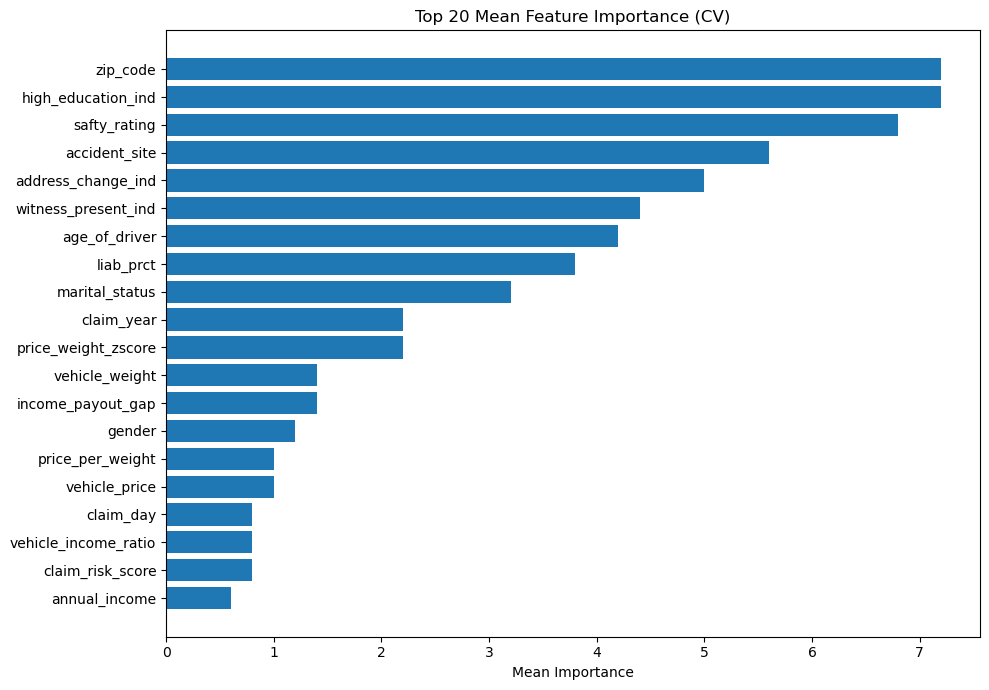

In [11]:
# =============================
# 8. Feature Importance 시각화
# =============================
top_k = 20

plt.figure(figsize=(10, 7))
plt.barh(
    mean_importance["feature"].head(top_k)[::-1],
    mean_importance["importance"].head(top_k)[::-1]
)
plt.title("Top 20 Mean Feature Importance (CV)")
plt.xlabel("Mean Importance")
plt.tight_layout()
plt.show()

In [12]:
# ======================
# 9. Threshold Tuning
# ======================
threshold_list = np.arange(0.05, 0.51, 0.05)

result_list = []

print("========== Threshold Tuning ==========")

for th in threshold_list:
    
    pred_label = (oof_pred >= th).astype(int)
    
    f1 = f1_score(y, pred_label)
    precision = precision_score(y, pred_label, zero_division=0)
    recall = recall_score(y, pred_label)
    
    tn, fp, fn, tp = confusion_matrix(y, pred_label).ravel()
    
    result_list.append({
        "threshold": th,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn
    })
    
    print(f"\nThreshold = {th:.2f}")
    print(f"F1        : {f1:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"TP={tp} FP={fp} FN={fn} TN={tn}")

result_df = pd.DataFrame(result_list)

========== Threshold Tuning ==========

Threshold = 0.05
F1        : 0.2732
Precision : 0.1582
Recall    : 1.0000
TP=2848 FP=15152 FN=0 TN=0

Threshold = 0.10
F1        : 0.2732
Precision : 0.1582
Recall    : 1.0000
TP=2848 FP=15152 FN=0 TN=0

Threshold = 0.15
F1        : 0.2745
Precision : 0.1591
Recall    : 0.9989
TP=2845 FP=15035 FN=3 TN=117

Threshold = 0.20
F1        : 0.3424
Precision : 0.2478
Recall    : 0.5541
TP=1578 FP=4791 FN=1270 TN=10361

Threshold = 0.25
F1        : 0.0000
Precision : 0.0000
Recall    : 0.0000
TP=0 FP=0 FN=2848 TN=15152

Threshold = 0.30
F1        : 0.0000
Precision : 0.0000
Recall    : 0.0000
TP=0 FP=0 FN=2848 TN=15152

Threshold = 0.35
F1        : 0.0000
Precision : 0.0000
Recall    : 0.0000
TP=0 FP=0 FN=2848 TN=15152

Threshold = 0.40
F1        : 0.0000
Precision : 0.0000
Recall    : 0.0000
TP=0 FP=0 FN=2848 TN=15152

Threshold = 0.45
F1        : 0.0000
Precision : 0.0000
Recall    : 0.0000
TP=0 FP=0 FN=2848 TN=15152

Threshold = 0.50
F1        : 0.000

In [13]:
best_row = result_df.loc[result_df["f1"].idxmax()]

print("\n========== Best Threshold ==========")
print(best_row)


========== Best Threshold ==========
threshold        0.200000
f1               0.342411
precision        0.247763
recall           0.554073
tp            1578.000000
fp            4791.000000
fn            1270.000000
tn           10361.000000
Name: 3, dtype: float64


In [14]:
# =====================
# 10. Recall@TopK 확인
# =====================
def recall_at_k(y_true, pred_prob, k_ratio=0.1):
    
    k = int(len(pred_prob) * k_ratio)
    
    top_idx = np.argsort(pred_prob)[::-1][:k]
    
    recall = y_true.iloc[top_idx].sum() / y_true.sum()
    
    return recall

In [15]:
k_list = [0.01, 0.03, 0.05, 0.10, 0.20, 0.30]

for k in k_list:
    recall_k = recall_at_k(y, oof_pred, k_ratio=k)
    print(f"Recall@Top{int(k*100)}%: {recall_k:.4f}")

Recall@Top1%: 0.0211
Recall@Top3%: 0.0614
Recall@Top5%: 0.0923
Recall@Top10%: 0.1893
Recall@Top20%: 0.3476
Recall@Top30%: 0.4895
